In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#  All Imports

In [2]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("TensorFlow:", tf.__version__)
print("All imports done ✓")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow: 2.20.0
All imports done ✓


# Config

In [3]:
DATASET_PATH = "/content/drive/MyDrive/AI and ML/Sarcastic or Not Sarcastic Dataset"
CSV_FILE     = "sarcastic_headlines.csv"

MAX_VOCAB    = 10000    # top 10,000 words in vocabulary
MAX_LEN      = 30       # max headline length (words)
EMBED_DIM    = 50       # embedding dimensions
BATCH_SIZE   = 64
EPOCHS       = 20
SEED         = 42

print("Config set ✓")

Config set ✓


# Load Dataset

In [4]:
df = pd.read_csv(os.path.join(DATASET_PATH, CSV_FILE))

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df['is_sarcastic'].value_counts())
print(f"\nSarcastic    : {df['is_sarcastic'].sum()} ({df['is_sarcastic'].mean()*100:.1f}%)")
print(f"Not Sarcastic: {(df['is_sarcastic']==0).sum()} ({(df['is_sarcastic']==0).mean()*100:.1f}%)")

Shape: (28619, 2)

First 5 rows:
                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1

Columns: ['headline', 'is_sarcastic']

Label distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Sarcastic    : 13634 (47.6%)
Not Sarcastic: 14985 (52.4%)


# Class Distribution Chart

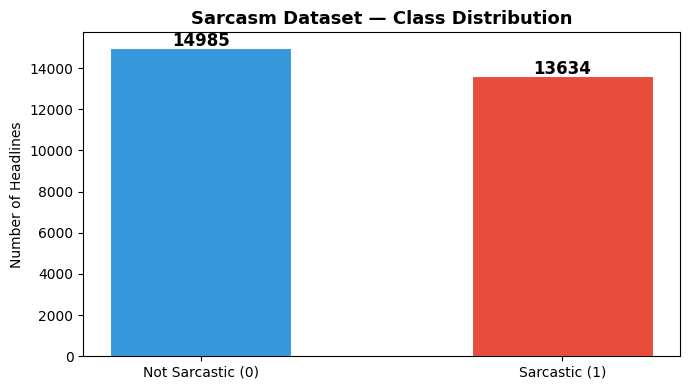

In [5]:
labels = ['Not Sarcastic (0)', 'Sarcastic (1)']
counts = df['is_sarcastic'].value_counts().sort_index().values

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts, color=['#3498db', '#e74c3c'],
               edgecolor='white', linewidth=0.8, width=0.5)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(count), ha='center',
             fontsize=12, fontweight='bold')

plt.title("Sarcasm Dataset — Class Distribution",
          fontsize=13, fontweight='bold')
plt.ylabel("Number of Headlines")
plt.tight_layout()
plt.show()

#  Clean Text Function

In [6]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Handle contractions
    contractions = {
        "don't":"do not", "can't":"cannot", "won't":"will not",
        "it's":"it is", "i'm":"i am", "i've":"i have",
        "i'll":"i will", "i'd":"i would", "he's":"he is",
        "she's":"she is", "that's":"that is", "there's":"there is",
        "they're":"they are", "we're":"we are", "you're":"you are",
        "isn't":"is not", "aren't":"are not", "wasn't":"was not",
        "weren't":"were not", "hasn't":"has not", "haven't":"have not",
        "didn't":"did not", "doesn't":"does not", "wouldn't":"would not"
    }
    for k, v in contractions.items():
        text = text.replace(k, v)
    # 5. Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 6. Remove stopwords + lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 1]
    return ' '.join(words)

print("clean_text function defined ✓")
print("\nExample:")
raw = "Scientists unveil doomsday clock of hair loss!"
print(f"  Before: {raw}")
print(f"  After : {clean_text(raw)}")

clean_text function defined ✓

Example:
  Before: Scientists unveil doomsday clock of hair loss!
  After : scientist unveil doomsday clock hair loss


# Apply Cleaning

In [7]:
print("Cleaning headlines...")
df['cleaned'] = df['headline'].apply(clean_text)

print(f"Done — {len(df)} headlines cleaned ✓")
print("\nSample cleaned headlines:")
for i in range(5):
    print(f"\n  Original : {df['headline'].iloc[i]}")
    print(f"  Cleaned  : {df['cleaned'].iloc[i]}")
    print(f"  Label    : {'Sarcastic' if df['is_sarcastic'].iloc[i] else 'Not Sarcastic'}")

Cleaning headlines...
Done — 28619 headlines cleaned ✓

Sample cleaned headlines:

  Original : thirtysomething scientists unveil doomsday clock of hair loss
  Cleaned  : thirtysomething scientist unveil doomsday clock hair loss
  Label    : Sarcastic

  Original : dem rep. totally nails why congress is falling short on gender, racial equality
  Cleaned  : dem rep totally nail congress falling short gender racial equality
  Label    : Not Sarcastic

  Original : eat your veggies: 9 deliciously different recipes
  Cleaned  : eat veggie deliciously different recipe
  Label    : Not Sarcastic

  Original : inclement weather prevents liar from getting to work
  Cleaned  : inclement weather prevents liar getting work
  Label    : Sarcastic

  Original : mother comes pretty close to using word 'streaming' correctly
  Cleaned  : mother come pretty close using word streaming correctly
  Label    : Sarcastic


# Word Cloud

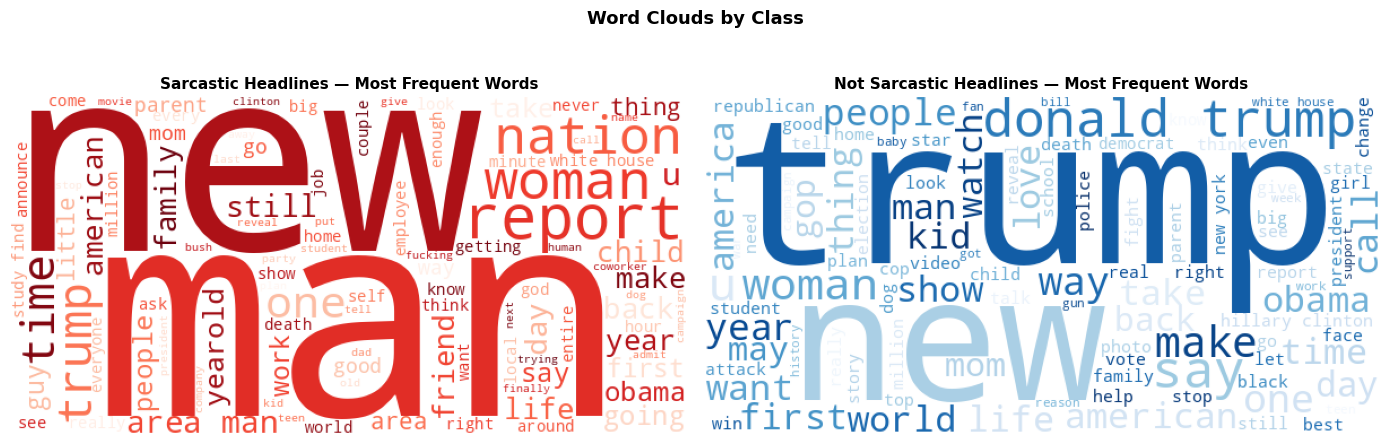

In [8]:
from wordcloud import WordCloud

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sarcastic
sarc_text = ' '.join(df[df['is_sarcastic']==1]['cleaned'])
wc1 = WordCloud(width=600, height=300, background_color='white',
                colormap='Reds', max_words=100).generate(sarc_text)
ax1.imshow(wc1); ax1.axis('off')
ax1.set_title('Sarcastic Headlines — Most Frequent Words',
              fontweight='bold', fontsize=11)

# Not Sarcastic
not_text = ' '.join(df[df['is_sarcastic']==0]['cleaned'])
wc2 = WordCloud(width=600, height=300, background_color='white',
                colormap='Blues', max_words=100).generate(not_text)
ax2.imshow(wc2); ax2.axis('off')
ax2.set_title('Not Sarcastic Headlines — Most Frequent Words',
              fontweight='bold', fontsize=11)

plt.suptitle("Word Clouds by Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tokenize + Pad

In [9]:
# Train / test split first
X = df['cleaned'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")

# Tokenize on training data ONLY
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"\nVocabulary size: {VOCAB_SIZE}")

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Check 95th percentile length
lengths = [len(s) for s in X_train_seq]
p95 = int(np.percentile(lengths, 95))
print(f"95th percentile sequence length: {p95} → using MAX_LEN = {MAX_LEN}")

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape : {X_test_pad.shape}")

Train size : 22895
Test size  : 5724

Vocabulary size: 10000
95th percentile sequence length: 11 → using MAX_LEN = 30

X_train_pad shape: (22895, 30)
X_test_pad shape : (5724, 30)


#  Build Model 1 (Simple RNN)

In [10]:
model1_rnn = Sequential([
    Embedding(input_dim    = VOCAB_SIZE,
              output_dim   = EMBED_DIM,
              input_length = MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name="Model1_SimpleRNN")

model1_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Build Model 2 (LSTM)

In [11]:
model2_lstm = Sequential([
    Embedding(input_dim    = VOCAB_SIZE,
              output_dim   = EMBED_DIM,
              input_length = MAX_LEN),
    LSTM(64, return_sequences=True),
    Dropout(0.4),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name="Model2_LSTM")

model2_lstm.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Build Word2Vec Embedding Matrix

In [15]:
import subprocess
import sys
import importlib

# Upgrade pip, setuptools, wheel first
print("Upgrading pip, setuptools, and wheel...")
result_upgrade = subprocess.run([sys.executable, "-m", "pip", "install",
                                 "--upgrade", "pip", "setuptools", "wheel", "--quiet"],
                                capture_output=True, text=True)
if result_upgrade.returncode != 0:
    print("Upgrade of pip tools failed:")
    print(result_upgrade.stdout)
    print(result_upgrade.stderr)
    raise RuntimeError("Failed to upgrade pip tools.")
else:
    print("Pip tools upgraded successfully.")

# Run gensim installation
print("Attempting to install gensim...")
result = subprocess.run([sys.executable, "-m", "pip", "install",
                         "gensim", "--quiet"],
                        capture_output=True, text=True)

if result.returncode != 0:
    print("Gensim installation failed:")
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError("Gensim installation failed. Check the logs above for details.")
else:
    print("Pip installation command executed successfully.")
    # Attempting to invalidate Python's internal import caches
    # This sometimes helps without a full kernel restart
    try:
        importlib.invalidate_caches()
        print("Import caches invalidated.")
    except Exception:
        pass # Ignore if this fails

print("Installing done — now loading GloVe model...")
print("This may take 2-3 minutes to download...")

import gensim.downloader as api
glove_model = api.load('glove-wiki-gigaword-50')

print(f"\nGloVe model loaded ✓")
print(f"Vocabulary size in GloVe: {len(glove_model)}")

Upgrading pip, setuptools, and wheel...
Pip tools upgraded successfully.
Attempting to install gensim...
Pip installation command executed successfully.
Import caches invalidated.
Installing done — now loading GloVe model...
This may take 2-3 minutes to download...

GloVe model loaded ✓
Vocabulary size in GloVe: 400000


# Build Embedding Matrix

In [16]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

found     = 0
not_found = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        found += 1
    else:
        not_found += 1

print(f"Words found in GloVe    : {found}")
print(f"Words NOT found in GloVe: {not_found}")
print(f"Coverage                : {found/(found+not_found)*100:.1f}%")
print(f"Embedding matrix shape  : {embedding_matrix.shape}")

Words found in GloVe    : 9701
Words NOT found in GloVe: 298
Coverage                : 97.0%
Embedding matrix shape  : (10000, 50)


# Build Model 3 (LSTM + GloVe)

In [17]:
model3_glove = Sequential([
    Embedding(input_dim    = VOCAB_SIZE,
              output_dim   = EMBED_DIM,
              weights      = [embedding_matrix],
              input_length = MAX_LEN,
              trainable    = False),      # frozen pretrained weights
    LSTM(64, return_sequences=True),
    Dropout(0.4),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name="Model3_LSTM_GloVe")

model3_glove.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

# Compile All 3 Models

In [18]:
def compile_model(model):
    model.compile(
        optimizer = 'adam',
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )

compile_model(model1_rnn)
compile_model(model2_lstm)
compile_model(model3_glove)

print("All 3 models compiled ✓")

All 3 models compiled ✓


#  Define Callbacks

In [19]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor              = 'val_loss',
            patience             = 4,
            restore_best_weights = True,
            verbose              = 1
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 2,
            verbose  = 1,
            min_lr   = 1e-6
        )
    ]

print("Callbacks defined ✓")

Callbacks defined ✓


#  Train Model 1 (Simple RNN)

In [20]:
print("=" * 45)
print("Training Model 1 — Simple RNN")
print("=" * 45)

start1 = time.time()

history1 = model1_rnn.fit(
    X_train_pad, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,
    callbacks       = get_callbacks()
)

time1 = time.time() - start1
print(f"\n✓ Model 1 done in {time1/60:.1f} min")
print(f"  Final Val Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Training Model 1 — Simple RNN
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.6918 - loss: 0.5746 - val_accuracy: 0.7712 - val_loss: 0.4842 - learning_rate: 0.0010
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8675 - loss: 0.3348 - val_accuracy: 0.7969 - val_loss: 0.4596 - learning_rate: 0.0010
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9329 - loss: 0.1893 - val_accuracy: 0.7852 - val_loss: 0.4833 - learning_rate: 0.0010
Epoch 4/20
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9665 - loss: 0.1038
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9613 - loss: 0.1123 - val_accuracy: 0.7699 - val_loss: 0.6726 - learning_rate: 0.0010
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9852 - loss: 0.0459 - val_accuracy: 0.7808 - val_loss: 0.7836 - learning_rate: 5.0000e-04
Epoch 6/20
320/322 ━━━━━━━━━━━━━━━━━━━━ 0s 16m

# Train Model 2 (LSTM)

In [21]:
print("=" * 45)
print("Training Model 2 — LSTM")
print("=" * 45)

start2 = time.time()

history2 = model2_lstm.fit(
    X_train_pad, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,
    callbacks       = get_callbacks()
)

time2 = time.time() - start2
print(f"\n✓ Model 2 done in {time2/60:.1f} min")
print(f"  Final Val Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Training Model 2 — LSTM
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.6927 - loss: 0.5619 - val_accuracy: 0.7939 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.8495 - loss: 0.3549 - val_accuracy: 0.7869 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.8897 - loss: 0.2749 - val_accuracy: 0.7913 - val_loss: 0.4572 - learning_rate: 0.0010
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9223 - loss: 0.2112
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.9123 - loss: 0.2290 - val_accuracy: 0.7825 - val_loss: 0.5079 - learning_rate: 0.0010
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 44s 101ms/step - accuracy: 0.9401 - loss: 0.1676 - val_accuracy: 0.7891 - val_loss: 0.6630 - learning_rate: 5.0000e-04
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/s

# Train Model 3 (LSTM + GloVe)

In [22]:
print("=" * 45)
print("Training Model 3 — LSTM + GloVe")
print("=" * 45)

start3 = time.time()

history3 = model3_glove.fit(
    X_train_pad, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,
    callbacks       = get_callbacks()
)

time3 = time.time() - start3
print(f"\n✓ Model 3 done in {time3/60:.1f} min")
print(f"  Final Val Accuracy: {max(history3.history['val_accuracy'])*100:.2f}%")

Training Model 3 — LSTM + GloVe
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.6775 - loss: 0.6038 - val_accuracy: 0.7288 - val_loss: 0.5430 - learning_rate: 0.0010
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.7372 - loss: 0.5309 - val_accuracy: 0.7541 - val_loss: 0.5007 - learning_rate: 0.0010
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.7642 - loss: 0.4934 - val_accuracy: 0.7092 - val_loss: 0.5514 - learning_rate: 0.0010
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.7808 - loss: 0.4662 - val_accuracy: 0.7646 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.7955 - loss: 0.4475 - val_accuracy: 0.7725 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8026 - loss: 0.4325 - val_accuracy: 0.7782 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 20s 

# Plot All 3 Training Curves Together

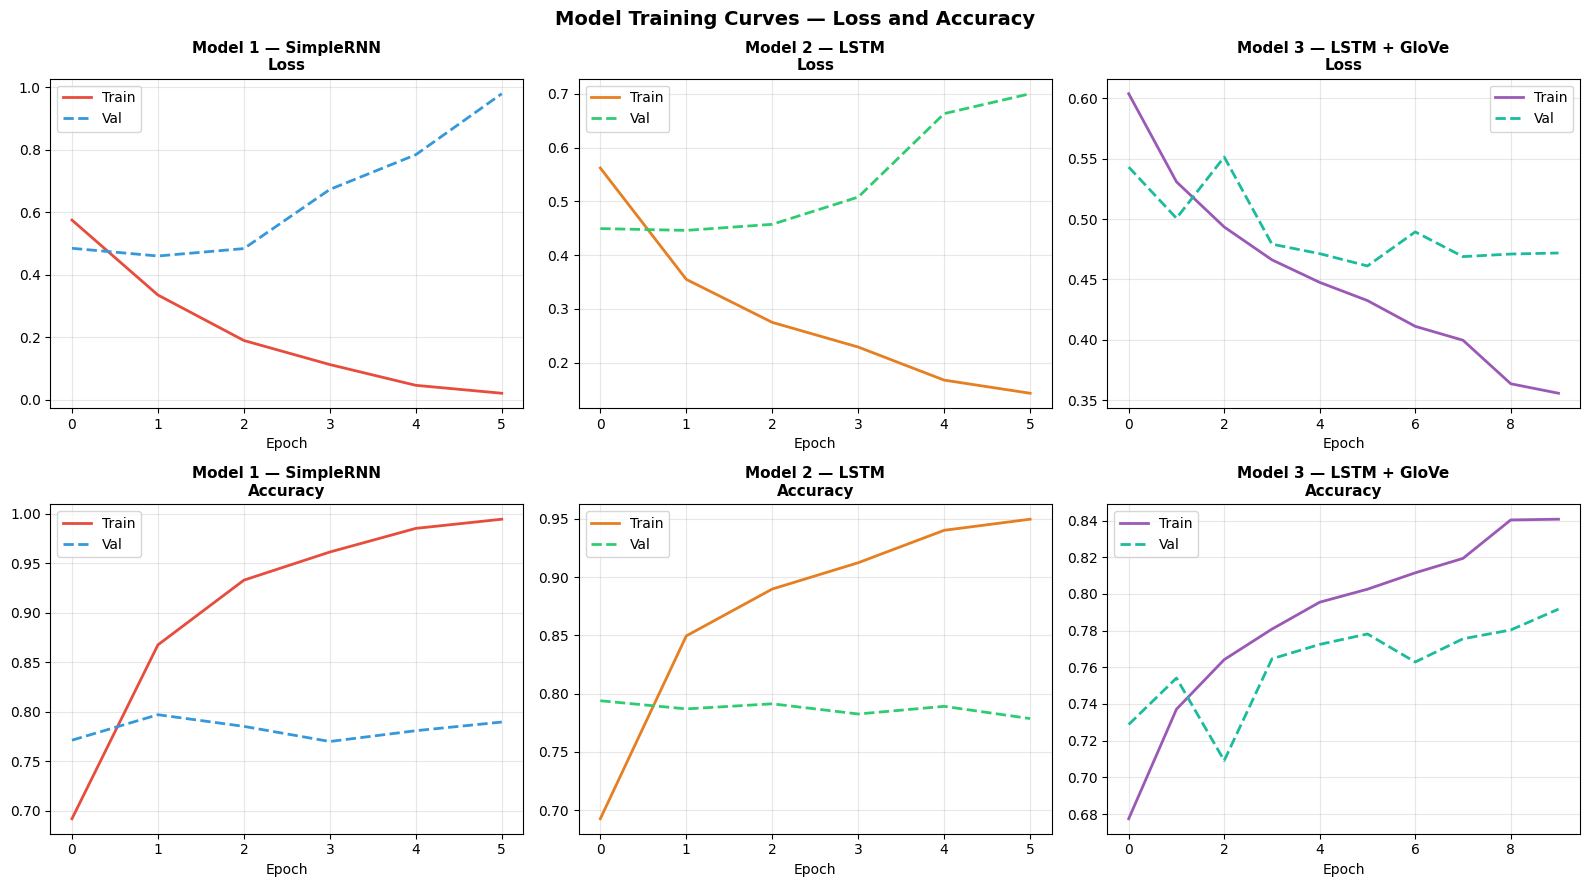

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Model Training Curves — Loss and Accuracy",
             fontsize=14, fontweight='bold')

models   = [history1, history2, history3]
names    = ["Model 1 — SimpleRNN",
            "Model 2 — LSTM",
            "Model 3 — LSTM + GloVe"]
colors   = [('#e74c3c','#3498db'),
            ('#e67e22','#2ecc71'),
            ('#9b59b6','#1abc9c')]

for i, (hist, name, (c1, c2)) in enumerate(zip(models, names, colors)):
    h = hist.history

    # Loss
    axes[0, i].plot(h['loss'],     label='Train', color=c1, lw=2)
    axes[0, i].plot(h['val_loss'], label='Val',   color=c2, lw=2, ls='--')
    axes[0, i].set_title(f"{name}\nLoss", fontsize=11, fontweight='bold')
    axes[0, i].legend(); axes[0, i].grid(alpha=0.3)
    axes[0, i].set_xlabel("Epoch")

    # Accuracy
    axes[1, i].plot(h['accuracy'],     label='Train', color=c1, lw=2)
    axes[1, i].plot(h['val_accuracy'], label='Val',   color=c2, lw=2, ls='--')
    axes[1, i].set_title(f"{name}\nAccuracy", fontsize=11, fontweight='bold')
    axes[1, i].legend(); axes[1, i].grid(alpha=0.3)
    axes[1, i].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

# Evaluate All 3 Models

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model_names = ["Model 1 — SimpleRNN",
               "Model 2 — LSTM",
               "Model 3 — LSTM + GloVe"]
models_list = [model1_rnn, model2_lstm, model3_glove]

all_results = {}

for name, model in zip(model_names, models_list):
    y_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    print("\n" + "="*55)
    print(f"  {name}")
    print("="*55)
    print(classification_report(
        y_test, y_pred,
        target_names=['Not Sarcastic', 'Sarcastic']
    ))
    all_results[name] = {
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'acc'    : np.mean(y_pred == y_test)
    }


  Model 1 — SimpleRNN
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.79      0.80      2997
    Sarcastic       0.77      0.79      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


  Model 2 — LSTM
               precision    recall  f1-score   support

Not Sarcastic       0.74      0.91      0.81      2997
    Sarcastic       0.86      0.64      0.74      2727

     accuracy                           0.78      5724
    macro avg       0.80      0.77      0.77      5724
 weighted avg       0.80      0.78      0.78      5724


  Model 3 — LSTM + GloVe
               precision    recall  f1-score   support

Not Sarcastic       0.75      0.83      0.79      2997
    Sarcastic       0.79      0.70      0.74      2727

     accuracy                           0.77      5724
    macro avg       0.77      0.76      0.77 

# Confusion Matrices (All 3)

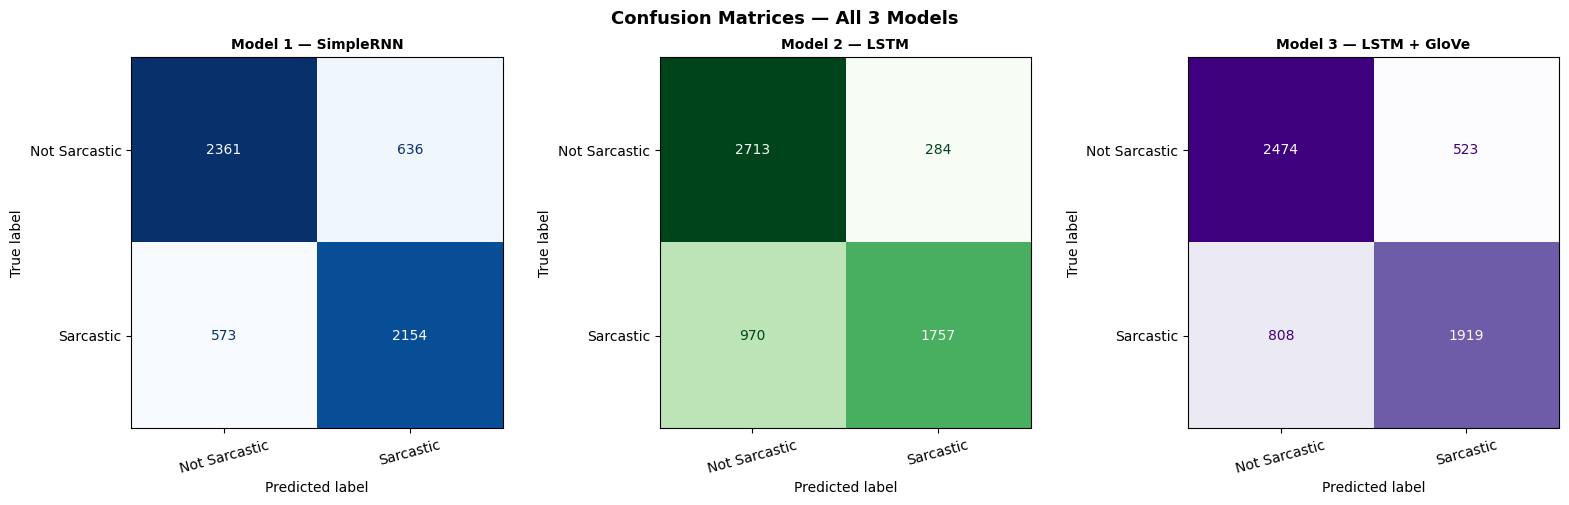

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — All 3 Models",
             fontsize=13, fontweight='bold')

cmaps = ['Blues', 'Greens', 'Purples']

for i, (name, model) in enumerate(zip(model_names, models_list)):
    y_pred = all_results[name]['y_pred']
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        cm, display_labels=['Not Sarcastic', 'Sarcastic']
    ).plot(ax=axes[i], cmap=cmaps[i], colorbar=False)
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Final Comparison Table

In [26]:
times = [time1, time2, time3]
histories = [history1, history2, history3]

print("="*70)
print("   FINAL MODEL COMPARISON — NLP TASK")
print("="*70)
print(f"{'Model':<30} {'Test Acc':>10} {'Val Acc':>10} {'Time(min)':>12}")
print("-"*70)

for name, model, hist, t in zip(model_names, models_list,
                                  histories, times):
    test_acc = all_results[name]['acc'] * 100
    val_acc  = max(hist.history['val_accuracy']) * 100
    print(f"{name:<30} {test_acc:>9.2f}% {val_acc:>9.2f}% {t/60:>11.1f}")

print("="*70)
print("\n✓ All 3 models trained, evaluated and compared")

   FINAL MODEL COMPARISON — NLP TASK
Model                            Test Acc    Val Acc    Time(min)
----------------------------------------------------------------------
Model 1 — SimpleRNN                78.88%     79.69%         1.1
Model 2 — LSTM                     78.09%     79.39%         2.9
Model 3 — LSTM + GloVe             76.75%     79.17%         2.8

✓ All 3 models trained, evaluated and compared


#  Error Analysis (Required by Brief)

In [27]:
print("ERROR ANALYSIS — Misclassified Examples")
print("="*55)

# Use best model — check which has highest test accuracy
best_name = max(all_results, key=lambda k: all_results[k]['acc'])
best_pred = all_results[best_name]['y_pred']

print(f"Analysing errors from: {best_name}\n")

wrong_idx = np.where(best_pred != y_test)[0]
print(f"Total misclassified: {len(wrong_idx)} of {len(y_test)}")
print(f"Error rate         : {len(wrong_idx)/len(y_test)*100:.2f}%\n")

# Show 5 wrong predictions
print("Sample wrong predictions:")
print("-"*55)
for i in wrong_idx[:5]:
    original  = X_test[i]
    true_lab  = "Sarcastic" if y_test[i] == 1 else "Not Sarcastic"
    pred_lab  = "Sarcastic" if best_pred[i] == 1 else "Not Sarcastic"
    print(f"Headline : {original}")
    print(f"True     : {true_lab}")
    print(f"Predicted: {pred_lab}")
    print()

ERROR ANALYSIS — Misclassified Examples
Analysing errors from: Model 1 — SimpleRNN

Total misclassified: 1209 of 5724
Error rate         : 21.12%

Sample wrong predictions:
-------------------------------------------------------
Headline : mother special
True     : Not Sarcastic
Predicted: Sarcastic

Headline : group christie campaign deserter found forest
True     : Sarcastic
Predicted: Not Sarcastic

Headline : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
True     : Sarcastic
Predicted: Not Sarcastic

Headline : rex tillerson call report ouster laughable
True     : Not Sarcastic
Predicted: Sarcastic

Headline : prayer answered random series event cold uncaring universe
True     : Sarcastic
Predicted: Not Sarcastic

